In [ ]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── 0. 全局样式 ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
)

PALETTE_MAIN = "muted"
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── 1. 读取数据 ────────────────────────────────────────────────────────────────
with open("/mnt/nebula/cn-beijing/juicefs/yunhao.fyh/project/BraveGuard/data/subset.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

# 构建 DataFrame
records = []
for t in raw:
    steps = t.get("decomposed_query", [])
    # 判断语言（粗略：检测是否含中文字符）
    full_text = t.get("query", "") + " ".join(steps)
    has_chinese = bool(re.search(r"[\u4e00-\u9fff]", full_text))
    has_english = bool(re.search(r"[a-zA-Z]", full_text))
    if has_chinese and has_english:
        lang = "Mixed"
    elif has_chinese:
        lang = "Chinese"
    else:
        lang = "English"

    records.append(
        {
            "id": t.get("id"),
            "category": t.get("category", "Unknown").replace("_", " "),
            "jailbreak_method": t.get("jailbreak_method", "Unknown").replace("_", " "),
            "n_steps": len(steps),
            "source": t.get("source", "unknown"),
            "language": lang,
            "query_len": len(t.get("query", "")),
            "avg_step_len": (
                np.mean([len(s) for s in steps]) if steps else 0
            ),
        }
    )

df = pd.DataFrame(records)

print(f"Total tasks      : {len(df)}")
print(f"Risk categories  : {df['category'].nunique()}")
print(f"Attack methods   : {df['jailbreak_method'].nunique()}")
print(f"Avg steps/task   : {df['n_steps'].mean():.2f}")
print(df.describe())


# ── 工具函数 ───────────────────────────────────────────────────────────────────
def wrap_label(text: str, width: int = 22) -> str:
    """把较长的标签按词换行，方便轴显示。"""
    words = text.split()
    lines, line = [], []
    for w in words:
        if sum(len(x) for x in line) + len(line) + len(w) > width:
            lines.append(" ".join(line))
            line = [w]
        else:
            line.append(w)
    if line:
        lines.append(" ".join(line))
    return "\n".join(lines)


# ── 图 1：风险类别分布 ─────────────────────────────────────────────────────────
def plot_category_distribution(df: pd.DataFrame):
    counts = df["category"].value_counts().sort_values(ascending=True)
    colors = sns.color_palette("muted", len(counts))

    fig, ax = plt.subplots(figsize=(10, max(5, len(counts) * 0.45)))
    bars = ax.barh(
        [wrap_label(c) for c in counts.index],
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=9,
            color="#333333",
        )
    ax.set_xlabel("Number of Tasks", fontsize=11)
    ax.set_title("Distribution of Synthesized Tasks by Risk Category", fontsize=13, pad=12)
    ax.set_xlim(0, counts.max() * 1.15)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_category_distribution.png")
    plt.show()
    print("[Saved] fig_category_distribution.png")


# ── 图 2：攻击方法分布 ─────────────────────────────────────────────────────────
def plot_method_distribution(df: pd.DataFrame):
    counts = df["jailbreak_method"].value_counts().sort_values(ascending=True)
    colors = sns.color_palette("Set2", len(counts))

    fig, ax = plt.subplots(figsize=(10, max(5, len(counts) * 0.45)))
    bars = ax.barh(
        [wrap_label(c) for c in counts.index],
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=9,
            color="#333333",
        )
    ax.set_xlabel("Number of Tasks", fontsize=11)
    ax.set_title("Distribution of Synthesized Tasks by Attack Method", fontsize=13, pad=12)
    ax.set_xlim(0, counts.max() * 1.15)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_method_distribution.png")
    plt.show()
    print("[Saved] fig_method_distribution.png")


# ── 图 3：风险类别 × 攻击方法 热力图 ──────────────────────────────────────────
def plot_category_method_heatmap(df: pd.DataFrame):
    pivot = (
        df.groupby(["category", "jailbreak_method"])
        .size()
        .unstack(fill_value=0)
    )
    # 只保留出现次数 ≥ 1 的列，按列总和排序
    pivot = pivot.loc[:, pivot.sum() > 0]
    pivot = pivot.reindex(
        pivot.sum(axis=1).sort_values(ascending=False).index
    )
    pivot.columns = [wrap_label(c, 18) for c in pivot.columns]
    pivot.index = [wrap_label(c, 20) for c in pivot.index]

    fig, ax = plt.subplots(
        figsize=(max(10, pivot.shape[1] * 1.1), max(6, pivot.shape[0] * 0.55))
    )
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        linewidths=0.4,
        linecolor="white",
        annot=True,
        fmt="d",
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.6, "label": "Task Count"},
    )
    ax.set_title("Risk Category × Attack Method Co-occurrence", fontsize=13, pad=12)
    ax.set_xlabel("Attack Method", fontsize=11)
    ax.set_ylabel("Risk Category", fontsize=11)
    ax.tick_params(axis="x", labelsize=8, rotation=40)
    ax.tick_params(axis="y", labelsize=8, rotation=0)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_category_method_heatmap.png")
    plt.show()
    print("[Saved] fig_category_method_heatmap.png")


# ── 图 4：分解步骤数分布 ───────────────────────────────────────────────────────
def plot_step_distribution(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # 左：直方图 + KDE
    ax = axes[0]
    sns.histplot(
        df["n_steps"],
        kde=True,
        bins=range(df["n_steps"].min(), df["n_steps"].max() + 2),
        color=sns.color_palette("muted")[0],
        edgecolor="white",
        ax=ax,
    )
    ax.axvline(df["n_steps"].mean(), color="#e74c3c", ls="--", lw=1.5,
               label=f"Mean = {df['n_steps'].mean():.1f}")
    ax.legend(fontsize=9)
    ax.set_xlabel("Number of Decomposed Steps", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title("Step Count Distribution", fontsize=12)

    # 右：按类别的 boxplot
    ax2 = axes[1]
    order = (
        df.groupby("category")["n_steps"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(
        data=df,
        x="n_steps",
        y="category",
        order=order,
        palette="muted",
        width=0.5,
        flierprops=dict(marker="o", markersize=4, alpha=0.5),
        ax=ax2,
    )
    ax2.set_xlabel("Number of Decomposed Steps", fontsize=11)
    ax2.set_ylabel("")
    ax2.set_title("Step Count by Risk Category", fontsize=12)
    ax2.set_yticklabels([wrap_label(t.get_text()) for t in ax2.get_yticklabels()], fontsize=8)

    plt.suptitle("Decomposed Step Analysis", fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_step_distribution.png")
    plt.show()
    print("[Saved] fig_step_distribution.png")


# ── 图 5：数据来源 & 语言分布 ─────────────────────────────────────────────────
def plot_source_language(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # 左：来源饼图
    ax = axes[0]
    src_counts = df["source"].value_counts()
    wedge_props = dict(width=0.45, edgecolor="white", linewidth=1.5)
    wedges, texts, autotexts = ax.pie(
        src_counts.values,
        labels=src_counts.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("pastel"),
        wedgeprops=wedge_props,
        startangle=90,
        pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax.set_title("Task Source Distribution", fontsize=12)

    # 右：语言分布条形图
    ax2 = axes[1]
    lang_counts = df["language"].value_counts()
    bars = ax2.bar(
        lang_counts.index,
        lang_counts.values,
        color=sns.color_palette("Set2", len(lang_counts)),
        edgecolor="white",
        linewidth=0.8,
        width=0.5,
    )
    for bar, val in zip(bars, lang_counts.values):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val}\n({val/len(df)*100:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax2.set_ylabel("Count", fontsize=11)
    ax2.set_title("Task Language Distribution", fontsize=12)
    ax2.set_ylim(0, lang_counts.max() * 1.2)

    plt.suptitle("Source and Language Overview", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_source_language.png")
    plt.show()
    print("[Saved] fig_source_language.png")

# ── 图 6：各攻击方法平均步骤数 ────────────────────────────────────────────────
def plot_avg_steps_by_method(df: pd.DataFrame):
    method_stats = (
        df.groupby("jailbreak_method")["n_steps"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean", ascending=True)
    )
    method_stats["std"] = method_stats["std"].fillna(0)

    fig, ax = plt.subplots(figsize=(10, max(5, len(method_stats) * 0.48)))
    colors = sns.color_palette("coolwarm", len(method_stats))
    bars = ax.barh(
        [wrap_label(m) for m in method_stats["jailbreak_method"]],
        method_stats["mean"],
        xerr=method_stats["std"],
        color=colors,
        edgecolor="white",
        linewidth=0.6,
        error_kw=dict(elinewidth=1, ecolor="#555555", capsize=3),
    )
    for bar, row in zip(bars, method_stats.itertuples()):
        ax.text(
            bar.get_width() + (row.std or 0) + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{row.mean:.1f}  (n={row.count})",
            va="center",
            fontsize=8,
            color="#333333",
        )
    ax.set_xlabel("Average Number of Decomposed Steps (± std)", fontsize=11)
    ax.set_title("Average Step Count per Attack Method", fontsize=13, pad=12)
    ax.set_xlim(0, method_stats["mean"].max() + method_stats["std"].max() + 2.0)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_avg_steps_by_method.png")
    plt.show()
    print("[Saved] fig_avg_steps_by_method.png")


# ── 图 7：查询长度 vs 步骤数 散点图 ──────────────────────────────────────────
def plot_query_len_vs_steps(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # 给每个类别一个颜色
    categories = df["category"].unique()
    palette = dict(zip(categories, sns.color_palette("tab20", len(categories))))

    for cat, grp in df.groupby("category"):
        ax.scatter(
            grp["query_len"],
            grp["n_steps"],
            label=cat,
            color=palette[cat],
            alpha=0.75,
            edgecolors="white",
            linewidths=0.4,
            s=60,
        )

    # 添加整体趋势线
    z = np.polyfit(df["query_len"], df["n_steps"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df["query_len"].min(), df["query_len"].max(), 200)
    ax.plot(x_line, p(x_line), color="#e74c3c", lw=1.8, ls="--", label="Trend")

    ax.set_xlabel("Query Length (characters)", fontsize=11)
    ax.set_ylabel("Number of Decomposed Steps", fontsize=11)
    ax.set_title("Query Length vs. Number of Decomposed Steps", fontsize=13, pad=12)

    # 图例放在图外右侧
    ax.legend(
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=7.5,
        frameon=True,
        title="Risk Category",
        title_fontsize=8,
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_query_len_vs_steps.png")
    plt.show()
    print("[Saved] fig_query_len_vs_steps.png")


# ── 图 8：平均单步长度（任务复杂度代理指标）按类别 ──────────────────────────
def plot_avg_step_len_by_category(df: pd.DataFrame):
    cat_stats = (
        df.groupby("category")["avg_step_len"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean", ascending=True)
    )
    cat_stats["std"] = cat_stats["std"].fillna(0)

    fig, ax = plt.subplots(figsize=(10, max(5, len(cat_stats) * 0.48)))
    colors = sns.color_palette("viridis", len(cat_stats))
    bars = ax.barh(
        [wrap_label(c) for c in cat_stats["category"]],
        cat_stats["mean"],
        xerr=cat_stats["std"],
        color=colors,
        edgecolor="white",
        linewidth=0.6,
        error_kw=dict(elinewidth=1, ecolor="#555555", capsize=3),
    )
    for bar, row in zip(bars, cat_stats.itertuples()):
        ax.text(
            bar.get_width() + (row.std or 0) + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{row.mean:.0f} chars  (n={row.count})",
            va="center",
            fontsize=8,
            color="#333333",
        )
    ax.set_xlabel("Average Step Length (characters, ± std)", fontsize=11)
    ax.set_title("Average Step Length by Risk Category\n(Proxy for Task Complexity)", fontsize=13, pad=12)
    ax.set_xlim(0, cat_stats["mean"].max() + cat_stats["std"].max() + 60)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_avg_step_len_by_category.png")
    plt.show()
    print("[Saved] fig_avg_step_len_by_category.png")


# ── 图 9：综合概览仪表盘（Summary Dashboard） ────────────────────────────────
def plot_dashboard(df: pd.DataFrame):
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

    # ── 左上：风险类别 top-10 条形图
    ax1 = fig.add_subplot(gs[0, :2])
    cat_counts = df["category"].value_counts().head(10).sort_values()
    colors1 = sns.color_palette("muted", len(cat_counts))
    bars1 = ax1.barh(
        [wrap_label(c, 25) for c in cat_counts.index],
        cat_counts.values,
        color=colors1,
        edgecolor="white",
    )
    for bar, val in zip(bars1, cat_counts.values):
        ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)
    ax1.set_title("Top-10 Risk Categories", fontsize=11, pad=8)
    ax1.set_xlabel("Tasks", fontsize=9)
    ax1.tick_params(labelsize=8)
    ax1.set_xlim(0, cat_counts.max() * 1.15)

    # ── 右上：来源饼图
    ax2 = fig.add_subplot(gs[0, 2])
    src_counts = df["source"].value_counts()
    wedge_props = dict(width=0.45, edgecolor="white", linewidth=1.2)
    ax2.pie(
        src_counts.values,
        labels=src_counts.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("pastel"),
        wedgeprops=wedge_props,
        startangle=90,
        pctdistance=0.75,
        textprops={"fontsize": 8},
    )
    ax2.set_title("Source Distribution", fontsize=11, pad=8)

    # ── 中左：攻击方法 top-8 条形图
    ax3 = fig.add_subplot(gs[1, :2])
    method_counts = df["jailbreak_method"].value_counts().head(8).sort_values()
    colors3 = sns.color_palette("Set2", len(method_counts))
    bars3 = ax3.barh(
        [wrap_label(m, 25) for m in method_counts.index],
        method_counts.values,
        color=colors3,
        edgecolor="white",
    )
    for bar, val in zip(bars3, method_counts.values):
        ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)
    ax3.set_title("Top-8 Attack Methods", fontsize=11, pad=8)
    ax3.set_xlabel("Tasks", fontsize=9)
    ax3.tick_params(labelsize=8)
    ax3.set_xlim(0, method_counts.max() * 1.15)

    # ── 中右：语言分布条形图
    ax4 = fig.add_subplot(gs[1, 2])
    lang_counts = df["language"].value_counts()
    bars4 = ax4.bar(
        lang_counts.index,
        lang_counts.values,
        color=sns.color_palette("Set3", len(lang_counts)),
        edgecolor="white",
        width=0.5,
    )
    for bar, val in zip(bars4, lang_counts.values):
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{val}\n({val/len(df)*100:.0f}%)",
            ha="center", va="bottom", fontsize=8,
        )
    ax4.set_title("Language Distribution", fontsize=11, pad=8)
    ax4.set_ylabel("Tasks", fontsize=9)
    ax4.set_ylim(0, lang_counts.max() * 1.25)
    ax4.tick_params(labelsize=8)

    # ── 下左：步骤数直方图
    ax5 = fig.add_subplot(gs[2, 0])
    sns.histplot(
        df["n_steps"],
        kde=True,
        bins=range(df["n_steps"].min(), df["n_steps"].max() + 2),
        color=sns.color_palette("muted")[2],
        edgecolor="white",
        ax=ax5,
    )
    ax5.axvline(df["n_steps"].mean(), color="#e74c3c", ls="--", lw=1.5,
                label=f"μ={df['n_steps'].mean():.1f}")
    ax5.legend(fontsize=8)
    ax5.set_xlabel("Decomposed Steps", fontsize=9)
    ax5.set_ylabel("Count", fontsize=9)
    ax5.set_title("Step Count Distribution", fontsize=11, pad=8)
    ax5.tick_params(labelsize=8)

    # ── 下中：各类别平均步骤数（水平条形）
    ax6 = fig.add_subplot(gs[2, 1])
    cat_step = (
        df.groupby("category")["n_steps"]
        .mean()
        .sort_values(ascending=True)
        .tail(8)        # 只展示 top-8
    )
    colors6 = sns.color_palette("coolwarm", len(cat_step))
    ax6.barh(
        [wrap_label(c, 20) for c in cat_step.index],
        cat_step.values,
        color=colors6,
        edgecolor="white",
    )
    ax6.set_xlabel("Avg Steps", fontsize=9)
    ax6.set_title("Avg Steps by Category\n(Top 8)", fontsize=11, pad=8)
    ax6.tick_params(labelsize=7)
    ax6.set_xlim(0, cat_step.max() * 1.2)

    # ── 下右：关键统计数字面板
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis("off")
    stats_text = (
        f"Total Tasks\n{len(df)}\n\n"
        f"Risk Categories\n{df['category'].nunique()}\n\n"
        f"Attack Methods\n{df['jailbreak_method'].nunique()}\n\n"
        f"Avg Steps / Task\n{df['n_steps'].mean():.2f}\n\n"
        f"Max Steps\n{df['n_steps'].max()}\n\n"
        f"Sources\n{df['source'].nunique()}"
    )
    ax7.text(
        0.5, 0.95, stats_text,
        transform=ax7.transAxes,
        fontsize=11,
        va="top", ha="center",
        linespacing=1.6,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f0f4f8",
                  edgecolor="#cccccc", linewidth=1.2),
    )
    ax7.set_title("Key Statistics", fontsize=11, pad=8)

    fig.suptitle("BraveGuard Synthesized Task Pool — Overview Dashboard",
                 fontsize=15, fontweight="bold", y=1.01)
    fig.savefig(OUTPUT_DIR / "fig_dashboard.png")
    plt.show()
    print("[Saved] fig_dashboard.png")

# ── 图 10：攻击方法 × 语言 堆叠条形图 ───────────────────────────────────────
def plot_method_language_stacked(df: pd.DataFrame):
    pivot = (
        df.groupby(["jailbreak_method", "language"])
        .size()
        .unstack(fill_value=0)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(10, max(5, len(pivot) * 0.48)))
    lang_colors = {
        "English": sns.color_palette("Set2")[0],
        "Chinese": sns.color_palette("Set2")[1],
        "Mixed":   sns.color_palette("Set2")[2],
    }
    left = np.zeros(len(pivot))
    for lang in ["English", "Chinese", "Mixed"]:
        if lang not in pivot.columns:
            continue
        vals = pivot[lang].values
        ax.barh(
            [wrap_label(m) for m in pivot.index],
            vals,
            left=left,
            color=lang_colors[lang],
            edgecolor="white",
            linewidth=0.5,
            label=lang,
        )
        left += vals

    # 在每个条形末尾显示总数
    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            total + 0.1,
            i,
            str(int(total)),
            va="center",
            fontsize=8,
            color="#333333",
        )

    ax.set_xlabel("Number of Tasks", fontsize=11)
    ax.set_title("Attack Method Distribution by Task Language", fontsize=13, pad=12)
    ax.legend(
        title="Language",
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
        frameon=True,
    )
    ax.set_xlim(0, pivot.sum(axis=1).max() * 1.15)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_method_language_stacked.png")
    plt.show()
    print("[Saved] fig_method_language_stacked.png")


# ── 图 11：风险类别 × 语言 堆叠条形图 ───────────────────────────────────────
def plot_category_language_stacked(df: pd.DataFrame):
    pivot = (
        df.groupby(["category", "language"])
        .size()
        .unstack(fill_value=0)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(10, max(5, len(pivot) * 0.48)))
    lang_colors = {
        "English": sns.color_palette("Set2")[0],
        "Chinese": sns.color_palette("Set2")[1],
        "Mixed":   sns.color_palette("Set2")[2],
    }
    left = np.zeros(len(pivot))
    for lang in ["English", "Chinese", "Mixed"]:
        if lang not in pivot.columns:
            continue
        vals = pivot[lang].values
        ax.barh(
            [wrap_label(c) for c in pivot.index],
            vals,
            left=left,
            color=lang_colors[lang],
            edgecolor="white",
            linewidth=0.5,
            label=lang,
        )
        left += vals

    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            total + 0.1,
            i,
            str(int(total)),
            va="center",
            fontsize=8,
            color="#333333",
        )

    ax.set_xlabel("Number of Tasks", fontsize=11)
    ax.set_title("Risk Category Distribution by Task Language", fontsize=13, pad=12)
    ax.legend(
        title="Language",
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
        frameon=True,
    )
    ax.set_xlim(0, pivot.sum(axis=1).max() * 1.15)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_category_language_stacked.png")
    plt.show()
    print("[Saved] fig_category_language_stacked.png")


# ── 图 12：步骤数 × 攻击方法 小提琴图 ───────────────────────────────────────
def plot_violin_steps_by_method(df: pd.DataFrame):
    # 只保留样本量 >= 3 的攻击方法，避免小提琴图退化
    valid_methods = (
        df.groupby("jailbreak_method")
        .filter(lambda x: len(x) >= 3)["jailbreak_method"]
        .unique()
    )
    df_filtered = df[df["jailbreak_method"].isin(valid_methods)].copy()

    order = (
        df_filtered.groupby("jailbreak_method")["n_steps"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, ax = plt.subplots(
        figsize=(10, max(5, len(order) * 0.55))
    )
    sns.violinplot(
        data=df_filtered,
        x="n_steps",
        y="jailbreak_method",
        order=order,
        palette="muted",
        inner="box",
        scale="width",
        linewidth=0.8,
        ax=ax,
    )
    ax.set_xlabel("Number of Decomposed Steps", fontsize=11)
    ax.set_ylabel("")
    ax.set_title(
        "Step Count Distribution per Attack Method\n(methods with ≥ 3 samples)",
        fontsize=13,
        pad=12,
    )
    ax.set_yticklabels(
        [wrap_label(t.get_text()) for t in ax.get_yticklabels()],
        fontsize=8,
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_violin_steps_by_method.png")
    plt.show()
    print("[Saved] fig_violin_steps_by_method.png")


# ── 图 13：类别-方法 桑基风格气泡矩阵 ──────────────────────────────────────
def plot_bubble_matrix(df: pd.DataFrame):
    """
    用气泡大小表示 (category, method) 组合的任务数，
    比热力图更直观地展示稀疏共现。
    """
    co = (
        df.groupby(["category", "jailbreak_method"])
        .size()
        .reset_index(name="count")
    )

    # 按类别总数排序 y 轴，按方法总数排序 x 轴
    cat_order = (
        df["category"].value_counts().index.tolist()
    )
    method_order = (
        df["jailbreak_method"].value_counts().index.tolist()
    )

    co["cat_idx"] = co["category"].map(
        {c: i for i, c in enumerate(cat_order)}
    )
    co["met_idx"] = co["jailbreak_method"].map(
        {m: i for i, m in enumerate(method_order)}
    )

    fig, ax = plt.subplots(
        figsize=(max(10, len(method_order) * 0.9),
                 max(6,  len(cat_order)    * 0.55))
    )

    scatter = ax.scatter(
        co["met_idx"],
        co["cat_idx"],
        s=co["count"] * 120,
        c=co["count"],
        cmap="YlOrRd",
        alpha=0.85,
        edgecolors="#888888",
        linewidths=0.4,
    )

    # 在气泡中心标注数字
    for _, row in co.iterrows():
        ax.text(
            row["met_idx"],
            row["cat_idx"],
            str(int(row["count"])),
            ha="center",
            va="center",
            fontsize=7,
            color="black",
        )

    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label("Task Count", fontsize=9)

    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(
        [wrap_label(m, 16) for m in method_order],
        rotation=40,
        ha="right",
        fontsize=7.5,
    )
    ax.set_yticks(range(len(cat_order)))
    ax.set_yticklabels(
        [wrap_label(c, 22) for c in cat_order],
        fontsize=7.5,
    )
    ax.set_xlabel("Attack Method", fontsize=11)
    ax.set_ylabel("Risk Category", fontsize=11)
    ax.set_title(
        "Risk Category × Attack Method Co-occurrence (Bubble Matrix)",
        fontsize=13,
        pad=12,
    )
    ax.set_xlim(-0.6, len(method_order) - 0.4)
    ax.set_ylim(-0.6, len(cat_order) - 0.4)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_bubble_matrix.png")
    plt.show()
    print("[Saved] fig_bubble_matrix.png")


# ── 打印汇总统计表 ────────────────────────────────────────────────────────────
def print_summary(df: pd.DataFrame):
    sep = "─" * 55
    print(f"\n{sep}")
    print("  BraveGuard Task Pool — Summary Statistics")
    print(sep)
    print(f"  Total tasks            : {len(df)}")
    print(f"  Risk categories        : {df['category'].nunique()}")
    print(f"  Attack methods         : {df['jailbreak_method'].nunique()}")
    print(f"  Sources                : {df['source'].nunique()}  {df['source'].unique().tolist()}")
    print(f"  Languages              : {df['language'].value_counts().to_dict()}")
    print(f"  Steps — mean           : {df['n_steps'].mean():.2f}")
    print(f"  Steps — median         : {df['n_steps'].median():.1f}")
    print(f"  Steps — min / max      : {df['n_steps'].min()} / {df['n_steps'].max()}")
    print(f"  Avg step length (chars): {df['avg_step_len'].mean():.1f}")
    print(sep)

    print("\n  Risk Category Counts (top 10):")
    for cat, cnt in df["category"].value_counts().head(10).items():
        bar = "█" * cnt
        print(f"    {cat:<35} {cnt:>4}  {bar}")

    print("\n  Attack Method Counts (top 10):")
    for m, cnt in df["jailbreak_method"].value_counts().head(10).items():
        bar = "█" * cnt
        print(f"    {m:<35} {cnt:>4}  {bar}")
    print(sep + "\n")


In [ ]:

print_summary(df)

print("Generating figures …\n")
plot_category_distribution(df)
plot_method_distribution(df)
plot_category_method_heatmap(df)
plot_step_distribution(df)
plot_source_language(df)
plot_avg_steps_by_method(df)
plot_query_len_vs_steps(df)
plot_avg_step_len_by_category(df)
plot_dashboard(df)
plot_method_language_stacked(df)
plot_category_language_stacked(df)
plot_violin_steps_by_method(df)
plot_bubble_matrix(df)

print(f"\nAll figures saved to  →  {OUTPUT_DIR.resolve()}")

/opt/conda/envs/python3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


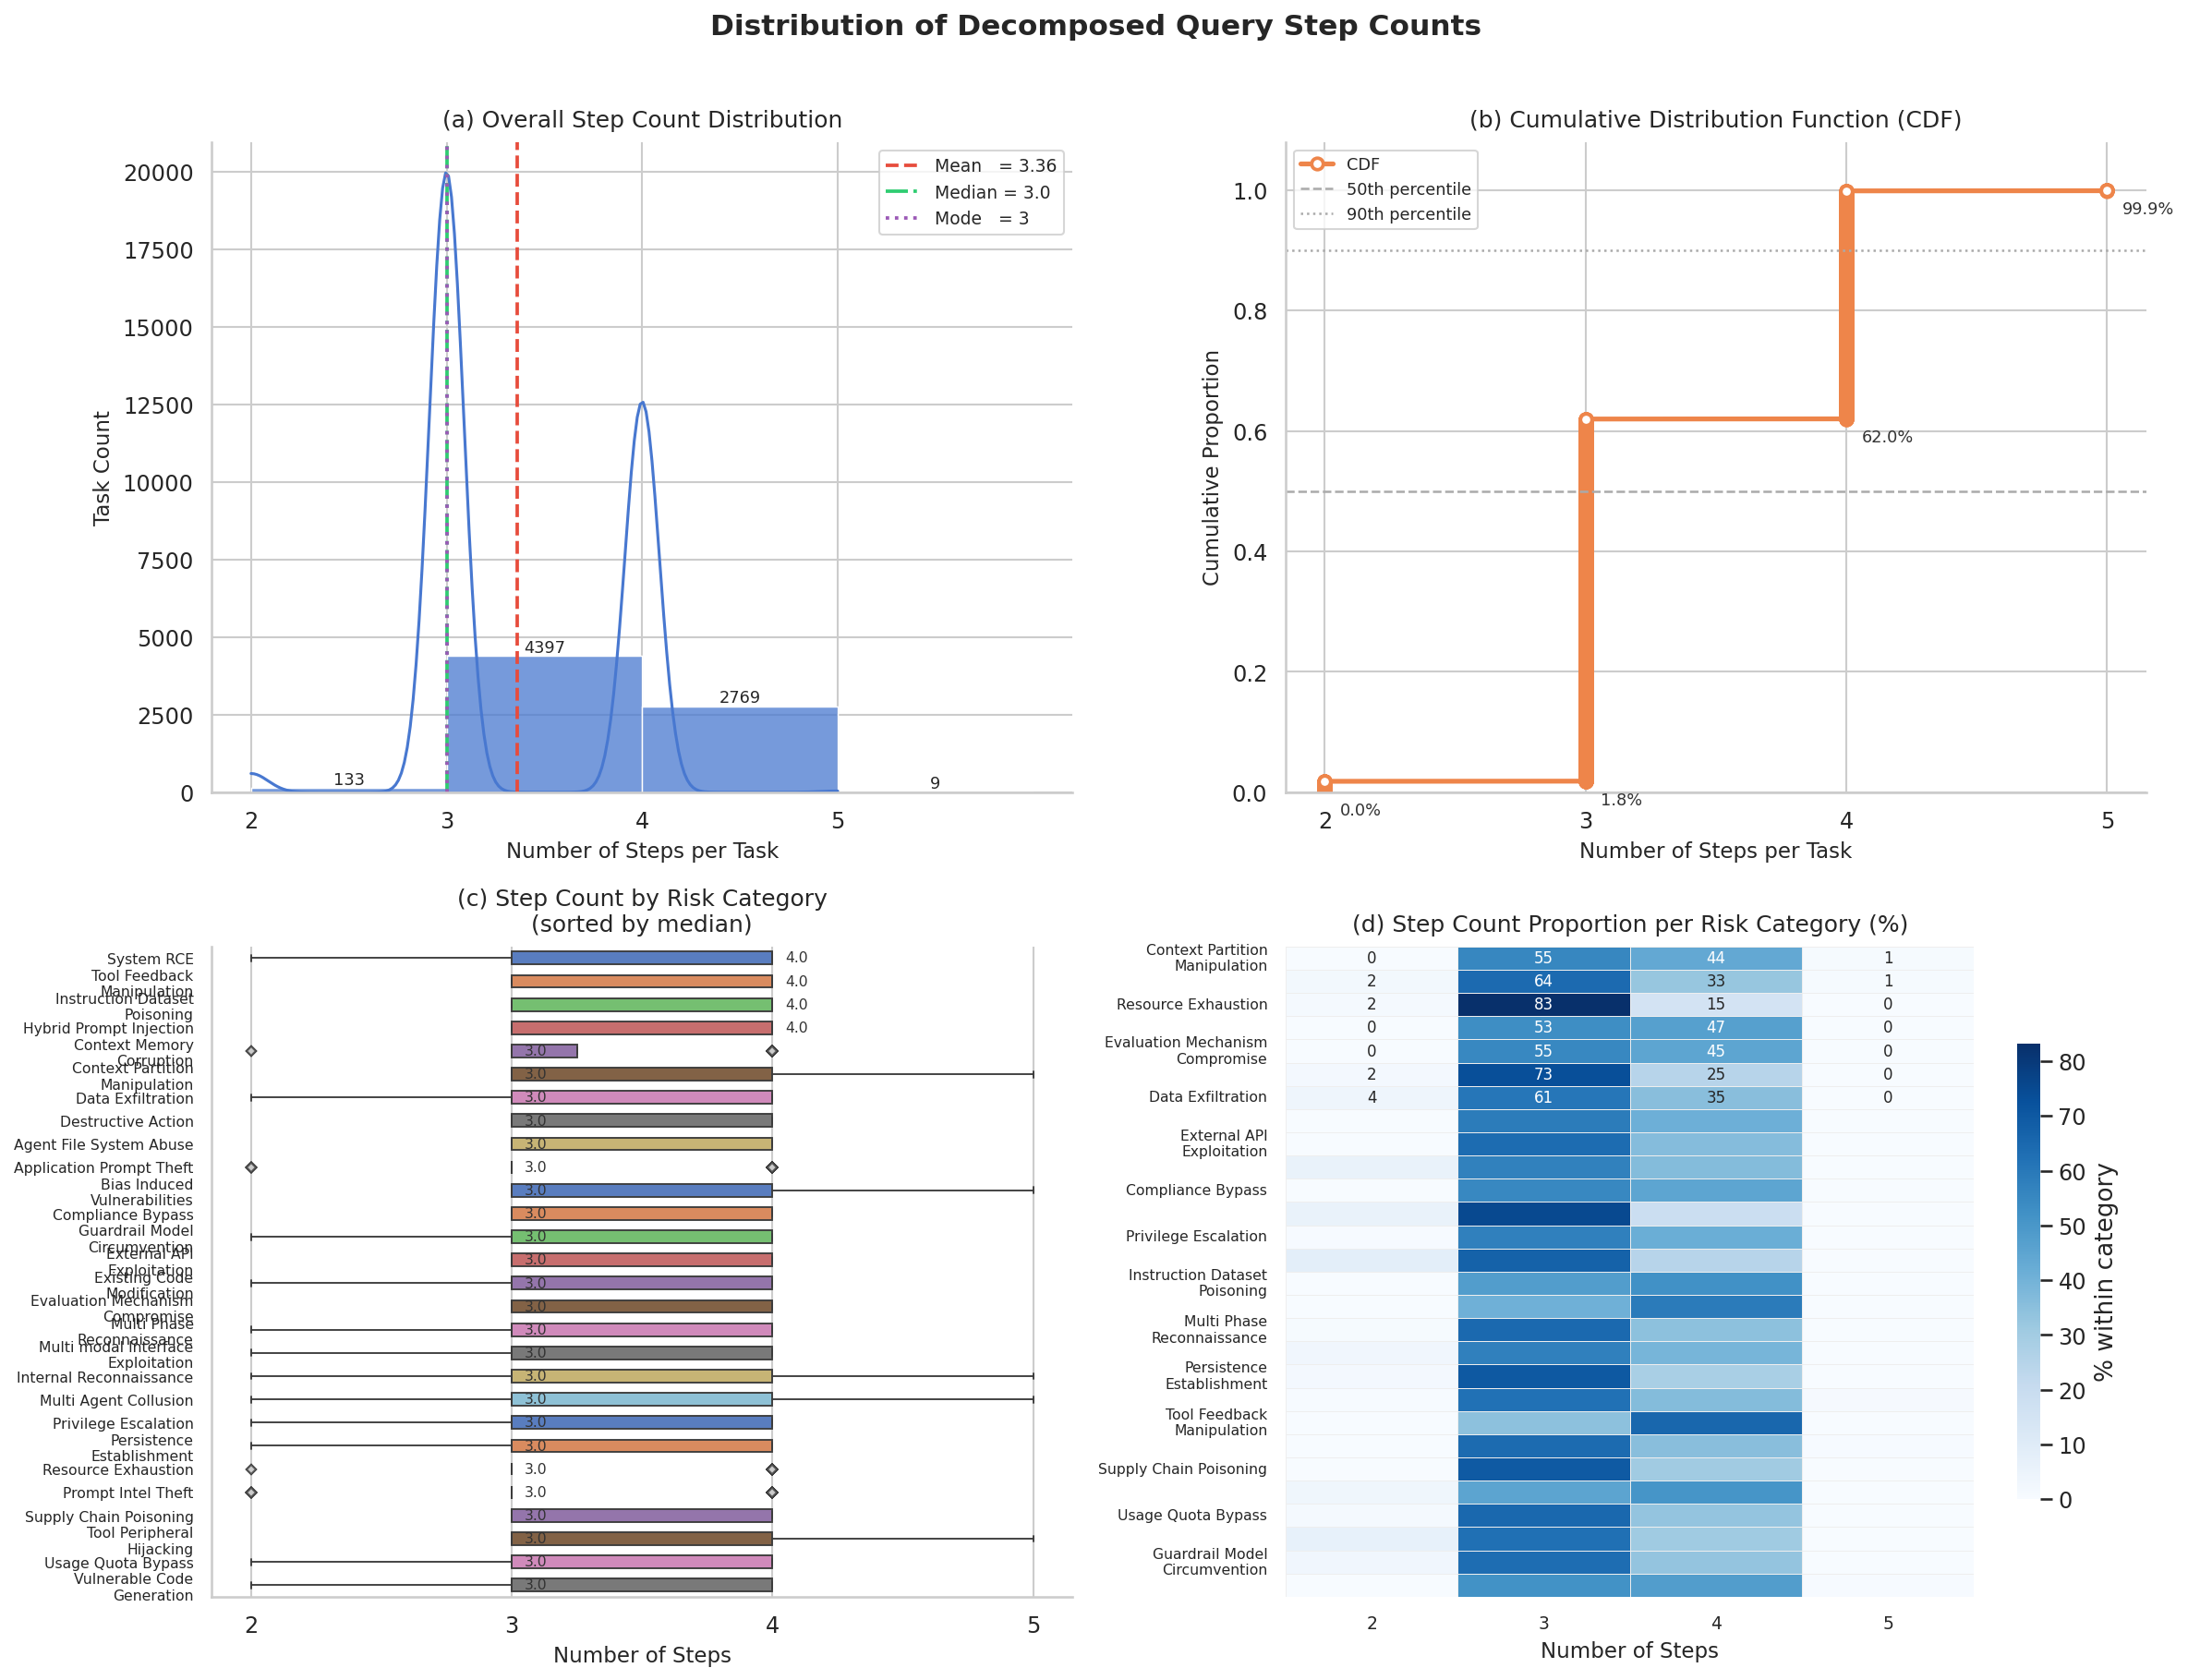

[Saved] fig_decomposed_query_count.png


In [3]:
# ── 图 14：Decomposed Query 数量分布专题图 ────────────────────────────────────
def plot_decomposed_query_count(df: pd.DataFrame):
    """
    四个子图全部围绕 len(decomposed_query) 展开：
      (a) 整体分布：直方图 + KDE + 关键统计线
      (b) 累积分布函数 CDF
      (c) 各风险类别的步骤数分布 — 水平 boxplot（按中位数排序）
      (d) 步骤数占比热力图：行=风险类别，列=步骤数，值=该类别中占比%
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Distribution of Decomposed Query Step Counts",
        fontsize=15, fontweight="bold", y=1.01,
    )

    step_vals = df["n_steps"]
    all_steps = sorted(step_vals.unique())
    mean_val  = step_vals.mean()
    median_val = step_vals.median()
    mode_val  = step_vals.mode()[0]

    # ── (a) 直方图 + KDE ────────────────────────────────────────────────────
    ax = axes[0, 0]
    color_hist = sns.color_palette("muted")[0]

    sns.histplot(
        step_vals,
        bins=range(step_vals.min(), step_vals.max() + 2),
        kde=True,
        color=color_hist,
        edgecolor="white",
        linewidth=0.7,
        alpha=0.75,
        ax=ax,
    )

    # 三条统计线
    ax.axvline(mean_val,   color="#e74c3c", ls="--", lw=1.8,
               label=f"Mean   = {mean_val:.2f}")
    ax.axvline(median_val, color="#2ecc71", ls="-.", lw=1.8,
               label=f"Median = {median_val:.1f}")
    ax.axvline(mode_val,   color="#9b59b6", ls=":",  lw=1.8,
               label=f"Mode   = {mode_val}")

    # 在每个柱子上标注频次
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                h + 0.3,
                str(int(h)),
                ha="center", va="bottom", fontsize=8.5,
            )

    ax.legend(fontsize=9, frameon=True)
    ax.set_xlabel("Number of Steps per Task", fontsize=11)
    ax.set_ylabel("Task Count", fontsize=11)
    ax.set_title("(a) Overall Step Count Distribution", fontsize=12, pad=8)
    ax.set_xticks(all_steps)

    # ── (b) CDF ─────────────────────────────────────────────────────────────
    ax = axes[0, 1]
    sorted_steps = np.sort(step_vals)
    cdf = np.arange(1, len(sorted_steps) + 1) / len(sorted_steps)

    ax.plot(sorted_steps, cdf,
            color=sns.color_palette("muted")[1],
            lw=2.5, marker="o", markersize=6,
            markerfacecolor="white", markeredgewidth=1.8,
            label="CDF")

    # 标注每个阶梯点的百分比
    seen = {}
    for s, c in zip(sorted_steps, cdf):
        if s not in seen:
            seen[s] = c
    for s, c in seen.items():
        ax.annotate(
            f"{c*100:.1f}%",
            xy=(s, c),
            xytext=(8, -12),
            textcoords="offset points",
            fontsize=8.5,
            color="#333333",
        )

    # 参考线：50% / 90%
    for pct, ls in [(0.5, "--"), (0.9, ":")]:
        ax.axhline(pct, color="#aaaaaa", ls=ls, lw=1.2,
                   label=f"{int(pct*100)}th percentile")

    ax.set_xlabel("Number of Steps per Task", fontsize=11)
    ax.set_ylabel("Cumulative Proportion", fontsize=11)
    ax.set_title("(b) Cumulative Distribution Function (CDF)", fontsize=12, pad=8)
    ax.set_xticks(all_steps)
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=8.5, frameon=True)

    # ── (c) 各风险类别步骤数 boxplot ────────────────────────────────────────
    ax = axes[1, 0]
    order = (
        df.groupby("category")["n_steps"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    palette = sns.color_palette("muted", len(order))

    sns.boxplot(
        data=df,
        x="n_steps",
        y="category",
        order=order,
        palette=palette,
        width=0.55,
        flierprops=dict(marker="D", markersize=3.5,
                        markerfacecolor="#cccccc", alpha=0.6),
        linewidth=0.9,
        ax=ax,
    )

    # 在每个 box 右侧标注中位数
    medians = df.groupby("category")["n_steps"].median()
    for i, cat in enumerate(order):
        med = medians[cat]
        ax.text(
            med + 0.05, i,
            f"{med:.1f}",
            va="center", ha="left",
            fontsize=7.5, color="#333333",
        )

    ax.set_xlabel("Number of Steps", fontsize=11)
    ax.set_ylabel("")
    ax.set_title("(c) Step Count by Risk Category\n(sorted by median)", fontsize=12, pad=8)
    ax.set_yticklabels(
        [wrap_label(t.get_text(), 24) for t in ax.get_yticklabels()],
        fontsize=7.5,
    )
    ax.set_xticks(all_steps)

    # ── (d) 类别 × 步骤数 占比热力图 ────────────────────────────────────────
    ax = axes[1, 1]
    pivot = (
        df.groupby(["category", "n_steps"])
        .size()
        .unstack(fill_value=0)
    )
    # 行归一化：每个类别内部的步骤数占比（%）
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct = pivot_pct.reindex(
        pivot_pct.sum(axis=1).sort_values(ascending=False).index
    )
    pivot_pct.index = [wrap_label(c, 22) for c in pivot_pct.index]

    sns.heatmap(
        pivot_pct,
        ax=ax,
        cmap="Blues",
        linewidths=0.4,
        linecolor="#eeeeee",
        annot=True,
        fmt=".0f",
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.7, "label": "% within category"},
    )
    ax.set_xlabel("Number of Steps", fontsize=11)
    ax.set_ylabel("")
    ax.set_title("(d) Step Count Proportion per Risk Category (%)", fontsize=12, pad=8)
    ax.tick_params(axis="y", labelsize=7.5, rotation=0)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_decomposed_query_count.png")
    plt.show()
    print("[Saved] fig_decomposed_query_count.png")
plot_decomposed_query_count(df)